In [232]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import yfinance as yf
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [233]:
usd_inr = yf.download("USDINR=X" , start='2025-01-01', end='2026-01-30',interval='1wk' )
usd_inr.reset_index(inplace=True)
usd_inr.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   (Date, )            57 non-null     datetime64[ns]
 1   (Close, USDINR=X)   57 non-null     float64       
 2   (High, USDINR=X)    57 non-null     float64       
 3   (Low, USDINR=X)     57 non-null     float64       
 4   (Open, USDINR=X)    57 non-null     float64       
 5   (Volume, USDINR=X)  57 non-null     int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.8 KB


In [234]:
#choosing the relavent coloumns
usd_inr = usd_inr[['Date', 'Close']]
usd_inr.columns = ['Date', 'USD_INR'] # changing the coloumn heading name 
usd_inr.head()

,Date,USD_INR
0,2025-01-01,85.680702
1,2025-01-08,86.650597
2,2025-01-15,86.211098
3,2025-01-22,86.468399
4,2025-01-29,86.943398


In [235]:

# ─────────────────────────────────────────────
# STEP 1: Load the CSV file
# ─────────────────────────────────────────────

# pd.read_csv() reads the file and loads it into a DataFrame (a table with rows and columns).
# index_col=False → prevents pandas from treating the first column (Date) as the row index.
#                   Without this, Date becomes the index and Gold values shift into the wrong column,
#                   causing all Gold values to appear as NaN (empty).
gold_rate = pd.read_csv("gold_daily.csv", index_col=False)


# ─────────────────────────────────────────────
# STEP 2: Remove rows where Date is empty
# ─────────────────────────────────────────────

# gold_rate['Date'].notna() → returns True for rows that have a value in the Date column,
#                             and False for rows that are completely empty.
# We use this to keep only rows that have a valid Date.
gold_rate = gold_rate[gold_rate['Date'].notna()]


# ─────────────────────────────────────────────
# STEP 3: Remove unwanted header rows
# ─────────────────────────────────────────────

# Some rows in the CSV contain the text "Gold Price" (repeated headers from the source).
# str.contains("Gold Price") → checks each Date value and returns True if it contains that text.
# na=False → treats any NaN values as False instead of raising an error.
rows_to_remove = gold_rate['Date'].str.contains("Gold Price", na=False)

# ~ (tilde) means NOT — so we keep only rows where the condition is False (i.e., not a header row).
gold_rate = gold_rate[~rows_to_remove]


# ─────────────────────────────────────────────
# STEP 4: Clean the Gold price column
# ─────────────────────────────────────────────

# The Gold column contains values like "?7,219.42" which have unwanted characters.
# We chain multiple .str methods to clean it step by step:

gold_rate['Gold'] = (
    gold_rate['Gold']
    .astype(str)                          # Convert all values to strings so we can use string methods
    .str.replace('?', '', regex=False)    # Remove the '?' character (currency symbol artifact).
                                          # regex=False → treat '?' as a plain character, not a regex pattern
    .str.replace(',', '', regex=False)    # Remove commas used as thousands separators (e.g. 7,219 → 7219)
)

# pd.to_numeric() → converts the cleaned string values into actual numbers (floats).
# errors='coerce' → if a value can't be converted (e.g. still has bad characters), it becomes NaN instead of crashing.
gold_rate['Gold'] = pd.to_numeric(gold_rate['Gold'], errors='coerce')


# ─────────────────────────────────────────────
# STEP 5: Drop rows where Gold is still NaN
# ─────────────────────────────────────────────

# After conversion, any rows that couldn't be parsed will have NaN in the Gold column.
# dropna(subset=['Gold']) → removes those rows, keeping only rows with a valid Gold price.
gold_rate = gold_rate.dropna(subset=['Gold'])


# ─────────────────────────────────────────────
# STEP 6: Convert the Date column to datetime
# ─────────────────────────────────────────────

# First parse everything as 2025
gold_rate['Date'] = pd.to_datetime(gold_rate['Date'] + '-2025', format='%d-%b-%Y')

# Find where the last block of January rows starts
# (i.e., January rows that come AFTER the other months)
last_jan_mask = (
    (gold_rate['Date'].dt.month == 1) &
    (gold_rate.index > gold_rate[gold_rate['Date'].dt.month != 1].index[-1])
)

# Update only those January rows to 2026
gold_rate.loc[last_jan_mask, 'Date'] = gold_rate.loc[last_jan_mask, 'Date'].apply(
    lambda d: d.replace(year=2026)
)

# ─────────────────────────────────────────────
# STEP 7: Reset the index
# ─────────────────────────────────────────────

# After all the filtering and dropping, the row numbers (index) will have gaps (e.g. 0, 2, 5...).
# reset_index(drop=True) → resets them back to a clean sequence starting from 0.
# drop=True → discards the old index instead of adding it as a new column.
gold_rate = gold_rate.reset_index(drop=True)


# ─────────────────────────────────────────────
# STEP 8: Compute weekly average
# ─────────────────────────────────────────────

# resample() works on time-based data, so we first set Date as the index.
gold_rate_indexed = gold_rate.set_index('Date')



FileNotFoundError: [Errno 2] No such file or directory: 'gold_daily.csv'

<Axes: xlabel='USD_INR', ylabel='Gold'>

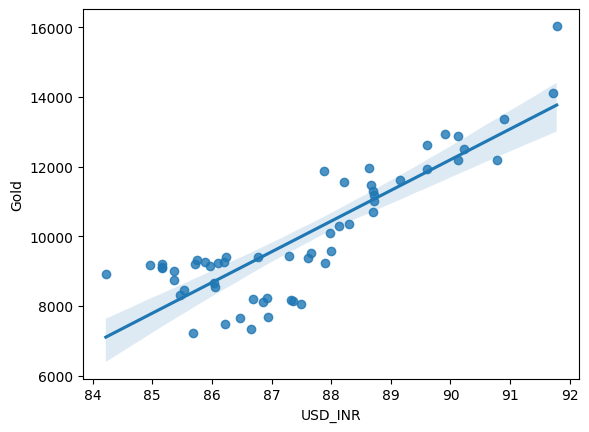

In [ ]:
gold_dataset = pd.read_csv('gold_dataset.csv')
sns.regplot(x='USD_INR',y='Gold' , data=gold_dataset)

In [ ]:
#model traning 

x = gold_dataset[['USD_INR']]
y = gold_dataset['Gold']


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
model  = LinearRegression()
model.fit(X_train,y_train)

 



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(X_test)


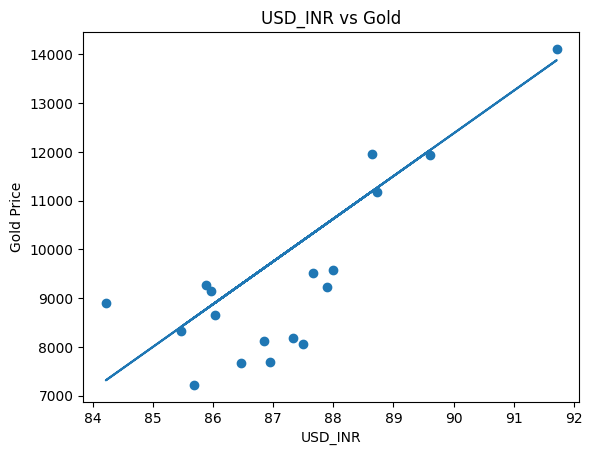

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("USD_INR")
plt.ylabel("Gold Price")
plt.title("USD_INR vs Gold")
plt.show()

In [ ]:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2_score(y_test, y_pred):.2f}")
print(f"MAE      : ₹{mae:.2f}")
print(f"RMSE     : ₹{rmse:.2f}")

R² Score : 0.54
MAE      : ₹975.29
RMSE     : ₹1198.94


In [236]:
#frontend developement 
import pickle

with open("gold_model.pkl", "wb") as f:
    pickle.dump(model, f)